In [1]:
import os, sys, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
sys.path.append('..')
import power_1loop

In [4]:
pt = power_1loop.PowerSpectrum1loop()

In [5]:
# Running the Boltzamann code (CAMB)
# (the integrations for the IR/UV limit of the power spectrum still raise a precision warning)

cparam = np.array([0.02225,0.1198,0.6844,3.094,0.9645,-1.]) # Planck 2015
pt.set_cosmology(cparam, z=0)

../power_1loop.py:206: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  res = quad(lambda k: self.get_pk_lin(k, khigh=khigh) * k**alpha, kmin, kmax, limit=limit)
../power_1loop.py:206: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  res = quad(lambda k: self.get_pk_lin(k, khigh=khigh) * k**alpha, kmin, kmax, limit=limit)


In [6]:
# Setting bias parameters. Here we need only b1.

bias = {'b1': 2}
pt.set_bias(bias)

In [7]:
# Output the linear theory P(k,mu) as numpy array of shape (len(k), len(mu))

k = np.linspace(1e-3,0.4,100)
mu = np.linspace(0,1,10)
pkmu = pt.get_pkmu_gg_lin(k, mu)

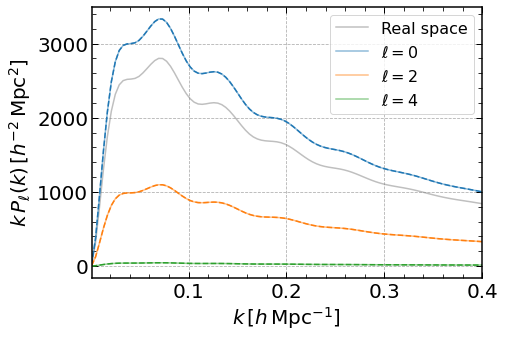

In [8]:
## Plot the linear theory P_l(k)

fig = plt.figure(figsize=(7,5))
color = ['gray','royalblue','orangered']
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ls_list = ['-','--','-.']

ax = fig.add_subplot(111)

k = np.linspace(1e-3,0.4,100)

pk = pkmu = pt.get_pkmu_gg_lin(k, 0)
ax.plot(k, k * pk, ls='-', c='gray', alpha=0.5, label=r'Real space')

for i, l in enumerate([0,2,4]):
    pl = pt.get_pl_gg_lin(l, k)
    ax.plot(k, k * pl, ls='-', c=color[i], alpha=0.5, label=r'$\ell = %s$' % (l))
    pl = pt.get_pl_gg_lin_analytic(l, k)
    ax.plot(k, k * pl, ls='--', c=color[i])
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_\ell(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16)
    plt.grid(linestyle='--')